<div style="
    background: linear-gradient(90deg, #8B1E3F 0%, #C44569 55%, #F8A5C2 100%);
    padding: 50px 35px;
    border-radius: 22px;
    color: white;
    text-align: center;
    box-shadow: 0 8px 25px rgba(139, 30, 63, 0.25);
    margin-bottom: 10px;
">

<div style="
        font-size: 18px;
        font-weight: 500;
        letter-spacing: 0.5px;
        margin-bottom: 14px;
    ">
        BinX Tech — AI & ML Internship · Week 9 · Day 3
    </div>

<div style="
        font-size: 34px;
        font-weight: 700;
        margin-bottom: 12px;
    ">
        Hands-On Lab — Streamlit Dashboard
    </div>

<div style="
        font-size: 20px;
        font-weight: 400;
        margin-bottom: 20px;
    ">
        Building an Interactive Interface for the ISIC Melanoma CNN
    </div>

<div style="
        font-size: 16px;
        font-weight: 400;
    ">
        Nadeen Shadeed · BinX Tech AI/ML Internship · 2026
    </div>

</div>

<div style="
    background: #fff5f8;
    border-left: 5px solid #C44569;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
 Lab Objective
</h3>

<p>
In this hands-on lab, we will build and test a Streamlit dashboard
for the serialized ISIC melanoma CNN model developed in the previous sprint.
</p>

<p>
The application will allow a user to upload a skin lesion image,
preprocess it using the same pipeline used during training,
run the CNN prediction, and display the predicted class,
confidence, and probability distribution.
</p>

<p>
The final application will provide a simple user-facing interface
for interacting with the trained machine learning model.
</p>

</div>

<div style="
    background: #faf7f2;
    border: 1px solid #eee5dc;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
What I Implemented
</h3>

<ul>
    <li>Loaded the serialized <code>.keras</code> CNN model.</li>
    <li>Cached the model using <code>@st.cache_resource</code>.</li>
    <li>Created an image upload widget using <code>st.file_uploader()</code>.</li>
    <li>Displayed the uploaded image in the dashboard.</li>
    <li>Applied the same preprocessing used during model training.</li>
    <li>Ran the CNN prediction on the uploaded image.</li>
    <li>Displayed the predicted class: Benign or Malignant.</li>
    <li>Displayed the confidence score.</li>
    <li>Visualized the Benign and Malignant probabilities.</li>
    <li>Tested the dashboard using sample images.</li>
</ul>

</div>

<div style="
    background: #fff5f8;
    border-left: 5px solid #C44569;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Project Architecture
</h3>

<p style="text-align: center; font-size: 18px; font-weight: 600;">
Training → Serialized CNN → Streamlit → User
</p>

<p>
The CNN was trained during the previous weeks and serialized as a
<code>.keras</code> model.
</p>

<p>
In this lab, Streamlit loads that model and provides a user interface
for uploading an image and viewing the prediction.
</p>

</div>

<div style="
    background: #fff5f8;
    border-left: 5px solid #C44569;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Environment Setup
</h3>

<p>
I installed the required Streamlit dependencies from the VS Code terminal.
</p>

<p>
The following command was executed in the terminal:
</p>

<pre style="
    background: #282828;
    color: #f5f5f5;
    padding: 16px;
    border-radius: 8px;
    overflow-x: auto;
"><code>pip install streamlit matplotlib</code></pre>

<p>
Streamlit is used to build the interactive dashboard, while Matplotlib
will be used for prediction probability visualization.
</p>

</div>

<div style="
    background: #faf7f2;
    border: 1px solid #eee5dc;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Import Libraries
</h3>

<p>
I imported the libraries required to build the Streamlit dashboard,
load the serialized CNN model, process uploaded images, and handle
the image data before prediction.
</p>

</div>

In [1]:
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
from pathlib import Path

<div style="
    background: #fff5f8;
    border-left: 5px solid #C44569;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Define the Model Path
</h3>

<p>
I defined the path to the serialized CNN model created during Day 1.
The model is reused directly instead of retraining it inside the
Streamlit application.
</p>

<p>
The application also uses the same input size that was used during
training: <code>112 × 112</code> RGB images.
</p>

</div>

In [4]:
MODEL_PATH = (
    Path("..")
    / "Day 1"
    / "models"
    / "melanoma_cnn.keras"
)

IMG_SIZE = (112, 112)

<div style="
    background: #faf7f2;
    border: 1px solid #eee5dc;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Load and Cache the CNN Model
</h3>

<p>
I created a model-loading function and used
<code>@st.cache_resource</code> to prevent Streamlit from loading
the CNN model again every time the application reruns.
</p>

<p>
This is important because Streamlit reruns the Python script whenever
the user interacts with the interface. Without caching, the model could
be loaded repeatedly, which would add unnecessary overhead.
</p>

</div>

In [5]:
@st.cache_resource
def load_model():
    return tf.keras.models.load_model(MODEL_PATH)

model = load_model()

2026-09-15 19:24:43.248 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


<div style="
    background: #fff5f8;
    border-left: 5px solid #C44569;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Configure the Streamlit Page
</h3>

<p>
I configured the basic page settings to give the dashboard a clear
title and a centered layout suitable for a simple image-classification
demo.
</p>

</div>

In [6]:
st.set_page_config(
    page_title="ISIC Melanoma Classifier",
    layout="centered"
)

2026-09-15 19:24:46.730 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


<div style="
    background: #faf7f2;
    border: 1px solid #eee5dc;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Create the Dashboard Interface
</h3>

<p>
I added a clear application title and a short description so that
a first-time user can immediately understand the purpose of the
dashboard.
</p>

</div>

In [7]:
st.title("ISIC Melanoma Classifier")

st.write(
    "Upload an ISIC skin lesion image to classify it as "
    "Benign or Malignant."
)

2026-09-15 19:24:49.656 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 19:24:51.288 
  command:

    streamlit run e:\BinX_AI_ML_Internship\.venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-15 19:24:51.292 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 19:24:51.299 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 19:24:51.304 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 19:24:51.305 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 19:24:51.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


<div style="
    background: #fff5f8;
    border-left: 5px solid #C44569;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Add the Image Upload Widget
</h3>

<p>
Since the CNN expects an image as its input, I used
<code>st.file_uploader()</code> to allow the user to upload a skin
lesion image directly through the dashboard.
</p>

<p>
The accepted formats are JPEG and PNG, matching the image formats
supported by the FastAPI endpoint implemented on Day 2.
</p>

</div>

In [8]:
uploaded_file = st.file_uploader(
    "Choose an image",
    type=["jpg", "jpeg", "png"]
)

2026-09-15 19:24:53.625 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 19:24:53.634 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 19:24:53.640 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 19:24:53.642 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-15 19:24:53.642 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


<div style="
    background: #faf7f2;
    border: 1px solid #eee5dc;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Display the Uploaded Image
</h3>

<p>
I displayed the uploaded image in the dashboard so the user can
visually confirm the selected input before running the prediction.
</p>

<p>
The image is also converted to RGB to ensure that the model receives
a consistent three-channel input format.
</p>

</div>

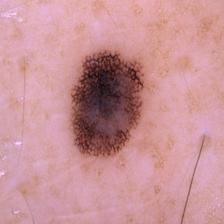

In [17]:
from pathlib import Path

image_path = Path(r"E:\BinX_AI_ML_Internship\Week7\Day 1\Data\train\Benign\3.jpg")

image = Image.open(image_path).convert("RGB")

image

<div style="
    background: #fff5f8;
    border-left: 5px solid #C44569;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Preprocess the Uploaded Image
</h3>

<p>
I applied the same preprocessing pipeline used during CNN training.
The uploaded image is resized to <code>112 × 112</code>, converted to a
NumPy array, normalized to the range <code>[0, 1]</code>, and expanded
with a batch dimension before being passed to the model.
</p>

</div>

In [18]:
img = image.resize(IMG_SIZE)

img_array = np.array(img) / 255.0

img_array = np.expand_dims(img_array, axis=0)

img_array.shape

(1, 112, 112, 3)

<div style="
    background: #faf7f2;
    border: 1px solid #eee5dc;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Run the CNN Prediction
</h3>

<p>
I passed the preprocessed image to the serialized CNN model.
Because the final layer uses a sigmoid activation, the model returns
a probability representing the likelihood of the Malignant class.
</p>

</div>

In [19]:
pred_prob = float(
    model.predict(img_array, verbose=0)[0][0]
)

pred_prob

0.38951754570007324

<div style="
    background: #fff5f8;
    border-left: 5px solid #C44569;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Convert Probability into a Class Prediction
</h3>

<p>
I used a threshold of <code>0.5</code> to convert the sigmoid probability
into the final class prediction.
</p>

<p>
A probability greater than or equal to <code>0.5</code> is classified as
<strong>Malignant</strong>, while a probability below <code>0.5</code>
is classified as <strong>Benign</strong>.
</p>

</div>

In [20]:
pred_class = (
    "Malignant" if pred_prob >= 0.5 else "Benign"
)

pred_class

'Benign'

<div style="
    background: #faf7f2;
    border: 1px solid #eee5dc;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Calculate Prediction Confidence
</h3>

<p>
I calculated the confidence as the probability of the predicted class.
For a Malignant prediction, the confidence is the Malignant probability.
For a Benign prediction, the confidence is the complement of the
Malignant probability.
</p>

</div>

In [21]:
confidence = (
    pred_prob if pred_prob >= 0.5
    else 1 - pred_prob
)

confidence

0.6104824542999268

<div style="
    background: #faf7f2;
    border: 1px solid #eee5dc;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Display the Prediction Result
</h3>

<p>
I displayed the predicted class and confidence score after running
the CNN inference.
</p>

<p>
The confidence represents the probability assigned to the predicted
class, rather than the overall accuracy of the model.
</p>

</div>

In [22]:
print(f"Prediction: {pred_class}")
print(f"Confidence: {confidence * 100:.2f}%")

Prediction: Benign
Confidence: 61.05%


<div style="
    background: #fff5f8;
    border-left: 5px solid #C44569;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Visualize Prediction Probabilities
</h3>

<p>
I calculated the probabilities for both classes and visualized them
to make the model prediction easier to interpret.
</p>

<p>
Because the CNN uses a sigmoid output for the Malignant class,
the Benign probability is calculated as <code>1 - pred_prob</code>.
</p>

</div>

In [23]:
benign_prob = 1 - pred_prob
malignant_prob = pred_prob

print(f"Benign: {benign_prob * 100:.2f}%")
print(f"Malignant: {malignant_prob * 100:.2f}%")

Benign: 61.05%
Malignant: 38.95%


<div style="
    background: #faf7f2;
    border: 1px solid #eee5dc;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Create a Probability Chart
</h3>

<p>
I created a simple bar chart to compare the probability assigned to
the Benign and Malignant classes.
</p>

<p>
This visualization provides a more informative view of the prediction
than showing the predicted class alone.
</p>

</div>

In [30]:
import matplotlib.pyplot as plt

labels = ["Benign", "Malignant"]
probabilities = [benign_prob, malignant_prob]

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(labels, probabilities)

ax.set_ylim(0, 1)
ax.set_ylabel("Probability")
ax.set_title("Prediction Probabilities")

for i, probability in enumerate(probabilities):
    ax.text(
        i,
        probability + 0.02,
        f"{probability * 100:.2f}%",
        ha="center"
    )

fig.tight_layout()

plot_path = Path("prediction_probabilities.png")
fig.savefig(plot_path, dpi=150)

print(f"Visualization saved to: {plot_path}")

Visualization saved to: prediction_probabilities.png


![alt text](image.png)

<div style="
    background: #fff5f8;
    border-left: 5px solid #C44569;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Build the Streamlit Application
</h3>

<p>
I combined the model loading, image upload, preprocessing, prediction,
confidence calculation, and probability visualization into a single
Streamlit application.
</p>

<p>
The application uses the serialized CNN model from Day 1 and applies
the same preprocessing pipeline used during training and testing.
</p>

<p>
The following code is the complete application implemented in
<code>streamlit_app.py</code>. It is documented here for reference
and is executed through the Streamlit server rather than inside
the Jupyter Notebook.
</p>

</div>

```python
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
from pathlib import Path


st.set_page_config(
    page_title="ISIC Melanoma Classifier",
    layout="centered"
)


MODEL_PATH = (
    Path(__file__).parent.parent.parent
    / "Day 1"
    / "models"
    / "melanoma_cnn.keras"
)

IMG_SIZE = (112, 112)


@st.cache_resource
def load_model():
    return tf.keras.models.load_model(MODEL_PATH)


model = load_model()


st.title("ISIC Melanoma Classifier")

st.write(
    "Upload an ISIC skin lesion image to classify it as "
    "Benign or Malignant."
)


uploaded_file = st.file_uploader(
    "Choose an image",
    type=["jpg", "jpeg", "png"]
)


if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")

    st.image(
        image,
        caption="Uploaded Image",
        width="stretch"
    )

    if st.button("Predict"):

        img = image.resize(IMG_SIZE)

        img_array = np.array(img) / 255.0

        img_array = np.expand_dims(img_array, axis=0)

        pred_prob = float(
            model.predict(
                img_array,
                verbose=0
            )[0][0]
        )

        pred_class = (
            "Malignant"
            if pred_prob >= 0.5
            else "Benign"
        )

        confidence = (
            pred_prob
            if pred_prob >= 0.5
            else 1 - pred_prob
        )

        benign_prob = 1 - pred_prob
        malignant_prob = pred_prob

        if pred_class == "Malignant":
            st.error(f"Prediction: {pred_class}")
        else:
            st.success(f"Prediction: {pred_class}")

        st.metric(
            "Confidence",
            f"{confidence * 100:.2f}%"
        )

        st.subheader("Prediction Probabilities")

        st.write(
            f"Benign: {benign_prob * 100:.2f}%"
        )
        st.progress(benign_prob)

        st.write(
            f"Malignant: {malignant_prob * 100:.2f}%"
        )
        st.progress(malignant_prob)


<div style="
    background: #faf7f2;
    border: 1px solid #eee5dc;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Run the Streamlit Application
</h3>

<p>
I ran the Streamlit application from the VS Code terminal rather than
from the Jupyter Notebook.
</p>

<p>
I first navigated to the application directory:
</p>

<pre style="
    background: #282828;
    color: #f5f5f5;
    padding: 16px;
    border-radius: 8px;
    overflow-x: auto;
"><code>cd "E:\BinX_AI_ML_Internship\Week9\Day 3\app"</code></pre>

<p>
Then I started the Streamlit server using:
</p>

<pre style="
    background: #282828;
    color: #f5f5f5;
    padding: 16px;
    border-radius: 8px;
    overflow-x: auto;
"><code>streamlit run streamlit_app.py</code></pre>

<p>
The application can then be accessed through the local Streamlit URL
provided in the terminal, typically
<code>http://localhost:8501</code>.
</p>

</div>

<div style="
    background: #faf7f2;
    border: 1px solid #eee5dc;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Streamlit Dashboard Preview
</h3>

<p>
After starting the Streamlit server, I opened the dashboard in the
browser and verified that the interface loaded correctly before
uploading any image.
</p>

<p>
The initial dashboard provides a clear title, a short description,
and an image uploader that accepts JPG, JPEG, and PNG files.
</p>

</div>

![alt text](<Screenshot 2026-09-15 195603.png>)

**Figure 1. Initial Streamlit dashboard before uploading an image.**

<div style="
    background: #fff5f8;
    border-left: 5px solid #C44569;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Test the Dashboard
</h3>

<p>
I tested the Streamlit dashboard using the same sample images that
were previously tested through the FastAPI endpoint.
</p>

<p>
Using the same images allows me to verify that the Streamlit interface
produces consistent predictions with the previously implemented API.
</p>

<ul>
    <li><code>3.jpg</code></li>
    <li><code>22.jpg</code></li>
    <li><code>64.jpg</code></li>
</ul>

<p>
For each image, I checked the uploaded image, predicted class,
confidence score, and class probabilities.
</p>

</div>

<div style="
    background: #fff5f8;
    border-left: 5px solid #C44569;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Image Upload and Prediction Interface
</h3>

<p>
I uploaded a sample lesion image through the Streamlit file uploader.
The dashboard displayed the selected image and provided the prediction
interface for running the CNN inference.
</p>

</div>

![alt text](<Screenshot 2026-09-15 195338.png>)

![alt text](<Screenshot 2026-09-15 195508.png>)

![alt text](<Screenshot 2026-09-15 195550.png>)

<div style="
    background: #fff5f8;
    border-left: 5px solid #C44569;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Streamlit Test Results
</h3>

<p>
I tested the Streamlit dashboard using three sample lesion images.
The predictions and confidence scores matched the results previously
obtained through the FastAPI service.
</p>

<table style="
    width: 100%;
    border-collapse: collapse;
    margin-top: 16px;
">
<tr style="background: #fff0f5;">
    <th style="padding: 10px; border: 1px solid #eee5dc;">Image</th>
    <th style="padding: 10px; border: 1px solid #eee5dc;">Prediction</th>
    <th style="padding: 10px; border: 1px solid #eee5dc;">Confidence</th>
    <th style="padding: 10px; border: 1px solid #eee5dc;">Status</th>
</tr>

<tr>
    <td style="padding: 10px; border: 1px solid #eee5dc;">3.jpg</td>
    <td style="padding: 10px; border: 1px solid #eee5dc;">Benign</td>
    <td style="padding: 10px; border: 1px solid #eee5dc;">61.05%</td>
    <td style="padding: 10px; border: 1px solid #eee5dc;">Passed</td>
</tr>

<tr>
    <td style="padding: 10px; border: 1px solid #eee5dc;">22.jpg</td>
    <td style="padding: 10px; border: 1px solid #eee5dc;">Benign</td>
    <td style="padding: 10px; border: 1px solid #eee5dc;">91.12%</td>
    <td style="padding: 10px; border: 1px solid #eee5dc;">Passed</td>
</tr>

<tr>
    <td style="padding: 10px; border: 1px solid #eee5dc;">64.jpg</td>
    <td style="padding: 10px; border: 1px solid #eee5dc;">Malignant</td>
    <td style="padding: 10px; border: 1px solid #eee5dc;">99.91%</td>
    <td style="padding: 10px; border: 1px solid #eee5dc;">Passed</td>
</tr>

</table>

<p style="margin-top: 18px;">
The dashboard also restricts uploads to supported image formats:
JPG, JPEG, and PNG.
</p>

</div>

<div style="
    background: #faf7f2;
    border: 1px solid #eee5dc;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Compare Streamlit with FastAPI
</h3>

<p>
I compared the Streamlit predictions with the results previously
obtained through the FastAPI service using the same sample images.
The results were consistent across both interfaces.
</p>

<table style="
    width: 100%;
    border-collapse: collapse;
    margin-top: 16px;
">
<tr style="background: #fff0f5;">
    <th style="padding: 10px; border: 1px solid #eee5dc;">Image</th>
    <th style="padding: 10px; border: 1px solid #eee5dc;">FastAPI</th>
    <th style="padding: 10px; border: 1px solid #eee5dc;">Streamlit</th>
    <th style="padding: 10px; border: 1px solid #eee5dc;">Result</th>
</tr>

<tr>
    <td style="padding: 10px; border: 1px solid #eee5dc;">3.jpg</td>
    <td style="padding: 10px; border: 1px solid #eee5dc;">Benign — 61.05%</td>
    <td style="padding: 10px; border: 1px solid #eee5dc;">Benign — 61.05%</td>
    <td style="padding: 10px; border: 1px solid #eee5dc;">Match</td>
</tr>

<tr>
    <td style="padding: 10px; border: 1px solid #eee5dc;">22.jpg</td>
    <td style="padding: 10px; border: 1px solid #eee5dc;">Benign — 91.12%</td>
    <td style="padding: 10px; border: 1px solid #eee5dc;">Benign — 91.12%</td>
    <td style="padding: 10px; border: 1px solid #eee5dc;">Match</td>
</tr>

<tr>
    <td style="padding: 10px; border: 1px solid #eee5dc;">64.jpg</td>
    <td style="padding: 10px; border: 1px solid #eee5dc;">Malignant — 99.91%</td>
    <td style="padding: 10px; border: 1px solid #eee5dc;">Malignant — 99.91%</td>
    <td style="padding: 10px; border: 1px solid #eee5dc;">Match</td>
</tr>

</table>

<p style="margin-top: 18px;">
FastAPI provides a programmatic API for sending prediction requests,
while Streamlit provides a user-friendly interface for interacting
with the same serialized CNN model.
</p>

</div>

<div style="
    background: #fff5f8;
    border-left: 5px solid #C44569;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Usability Check
</h3>

<p>
I reviewed the dashboard from a user perspective to make sure the
main prediction workflow is clear and easy to follow.
</p>

<ul>
    <li>The dashboard clearly explains what the application does.</li>
    <li>The image uploader accepts only supported image formats.</li>
    <li>The uploaded image is displayed before prediction.</li>
    <li>The prediction result is displayed prominently.</li>
    <li>The confidence score is shown as a percentage.</li>
    <li>Both Benign and Malignant probabilities are visualized.</li>
    <li>The interface focuses on one main task: uploading an image and obtaining a CNN prediction.</li>
</ul>

<p>
The dashboard provides a simple interaction flow without requiring
the user to understand the underlying Python code or machine learning
implementation.
</p>

</div>

<div style="
    background: #faf7f2;
    border: 1px solid #eee5dc;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Pull Request & Code Review
</h3>

<p>
I prepared the Day 3 Streamlit dashboard changes for a pull request
and mentor code review.
</p>

<p>
The review focuses on the following areas:
</p>

<ul>
    <li>Correct loading of the serialized <code>.keras</code> model.</li>
    <li>Consistent image preprocessing between training and inference.</li>
    <li>Correct prediction and confidence calculation.</li>
    <li>Clear and focused Streamlit user interface.</li>
    <li>Efficient model loading using <code>@st.cache_resource</code>.</li>
    <li>Readable code structure and maintainability.</li>
</ul>

<p>
Any feedback received during the review will be addressed before
moving to the public deployment stage.
</p>

</div>

<div style="
    background: #fff5f8;
    border-left: 5px solid #C44569;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Day 3 Results
</h3>

<p>
I transformed the serialized ISIC Melanoma CNN model into an
interactive Streamlit dashboard for image-based prediction.
</p>

<ul>
    <li>Loaded the serialized <code>.keras</code> CNN model.</li>
    <li>Used <code>@st.cache_resource</code> to cache the model.</li>
    <li>Added an image uploader for JPG, JPEG, and PNG files.</li>
    <li>Displayed the uploaded image before prediction.</li>
    <li>Applied the same preprocessing used during model training.</li>
    <li>Generated Benign and Malignant predictions using the CNN.</li>
    <li>Displayed the predicted class and confidence score.</li>
    <li>Visualized the probabilities for both classes.</li>
    <li>Tested the dashboard using three sample images.</li>
    <li>Verified that Streamlit produced the same results as FastAPI.</li>
</ul>

<p>
The Streamlit dashboard provides a human-facing interface, while
FastAPI provides a programmatic interface for accessing the same
serialized CNN model.
</p>

</div>

<div style="
    background: #faf7f2;
    border: 1px solid #eee5dc;
    border-radius: 12px;
    padding: 26px 30px;
    color: #3F3A38;
">

<h3 style="color: #8B1E3F; margin-top: 0;">
Key Takeaways
</h3>

<ul>
    <li>
        <strong>Streamlit</strong> can turn a trained ML model into an
        interactive user-facing web application.
    </li>

<li>
        <strong><code>st.file_uploader()</code></strong> is suitable for
        receiving image inputs from users.
    </li>

<li>
        <strong><code>@st.cache_resource</code></strong> prevents the CNN
        model from being unnecessarily reloaded during Streamlit reruns.
    </li>

<li>
        <strong>Inference preprocessing must match training preprocessing</strong>
        to ensure consistent model input.
    </li>

<li>
        The CNN's <strong>sigmoid output</strong> represents the probability
        of the <strong>Malignant</strong> class.
    </li>

<li>
        A threshold of <strong>0.5</strong> is used to convert the probability
        into the predicted class.
    </li>

<li>
        <strong>Confidence</strong> represents the probability assigned to
        the predicted class, not the overall model accuracy.
    </li>

<li>
        <strong>FastAPI</strong> provides a programmatic API, while
        <strong>Streamlit</strong> provides an interactive interface for
        human users.
    </li>

<li>
        The same serialized CNN model can be served through multiple
        interfaces without retraining the model.
    </li>

</ul>

<p style="margin-top: 18px;">
The main goal of Day 3 was to move from a model that can make
predictions through code to an application that a user can interact
with directly.
</p>

</div>